<a href="https://colab.research.google.com/github/R0dr1go1331/Laboratorio-2/blob/main/predictionPY.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00468/online_shoppers_intention.csv"

print("--- CARGANDO DATASET: ONLINE SHOPPERS PURCHASING INTENTION ---")
# Leer el dataset
df = pd.read_csv(url)

# Obtener dimensiones
total_registros = df.shape[0]
total_variables = df.shape[1]

print("--- DIMENSIONES DEL DATASET OFICIAL ---")
print(f"Total de registros (Sesiones de clientes): {total_registros:,}")
print(f"Total de variables (Features + Target): {total_variables}\n")

# Visualizar las primeras filas
print("--- PRIMERAS 5 FILAS DEL DATASET ---")
display(df.head())

--- CARGANDO DATASET: ONLINE SHOPPERS PURCHASING INTENTION ---
--- DIMENSIONES DEL DATASET OFICIAL ---
Total de registros (Sesiones de clientes): 12,330
Total de variables (Features + Target): 18

--- PRIMERAS 5 FILAS DEL DATASET ---


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [5]:
import pandas as pd

# Definimos el diccionario de datos para nuestras variables seleccionadas
diccionario_datos = {
    'Variable': [
        'Administrative', 'Administrative_Duration', 'ProductRelated',
        'BounceRates', 'PageValues', 'SpecialDay',
        'Month', 'VisitorType', 'Weekend', 'Revenue'
    ],
    'Descripción': [
        'Cantidad de páginas administrativas visitadas', 'Tiempo total (seg) en páginas administrativas',
        'Cantidad de páginas de producto visitadas', 'Tasa de rebote (usuarios que salen sin interactuar)',
        'Valor promedio de las páginas visitadas', 'Proximidad a una fecha especial (ej. Día de la Madre)',
        'Mes de la visita', 'Categoría del visitante',
        '¿La visita ocurrió en fin de semana?', '¿La sesión terminó en compra?'
    ],
    'Tipo (Estadístico)': [
        'Numérica (Discreta)', 'Numérica (Continua)', 'Numérica (Discreta)',
        'Numérica (Continua)', 'Numérica (Continua)', 'Numérica (Continua)',
        'Categórica (Nominal)', 'Categórica (Nominal)', 'Booleana', 'Booleana'
    ],
    'Rol': [
        'Feature', 'Feature', 'Feature',
        'Feature', 'Feature', 'Feature',
        'Feature', 'Feature', 'Feature', 'Target'
    ],
    'Valores Posibles': [
        '0, 1, 2...', '0.0 a N', '0, 1, 2...',
        '0.0 a 0.2', '0.0 a N', '0.0 a 1.0',
        'Feb, Mar, May...', 'Returning_Visitor, New_Visitor...',
        'True / False', 'True / False'
    ]
}

df_diccionario = pd.DataFrame(diccionario_datos)

print("--- DICCIONARIO DE DATOS ---")
display(df_diccionario)

--- DICCIONARIO DE DATOS ---


,Variable,Descripción,Tipo (Estadístico),Rol,Valores Posibles
0,Administrative,Cantidad de páginas administrativas visitadas,Numérica (Discreta),Feature,"0, 1, 2..."
1,Administrative_Duration,Tiempo total (seg) en páginas administrativas,Numérica (Continua),Feature,0.0 a N
2,ProductRelated,Cantidad de páginas de producto visitadas,Numérica (Discreta),Feature,"0, 1, 2..."
3,BounceRates,Tasa de rebote (usuarios que salen sin interac...,Numérica (Continua),Feature,0.0 a 0.2
4,PageValues,Valor promedio de las páginas visitadas,Numérica (Continua),Feature,0.0 a N
5,SpecialDay,Proximidad a una fecha especial (ej. Día de la...,Numérica (Continua),Feature,0.0 a 1.0
6,Month,Mes de la visita,Categórica (Nominal),Feature,"Feb, Mar, May..."
7,VisitorType,Categoría del visitante,Categórica (Nominal),Feature,"Returning_Visitor, New_Visitor..."
8,Weekend,¿La visita ocurrió en fin de semana?,Booleana,Feature,True / False
9,Revenue,¿La sesión terminó en compra?,Booleana,Target,True / False


In [6]:
import pandas as pd

# (Asumiendo que el dataset ya está cargado de la variable 'df' en la celda anterior)
# Para asegurar que la celda corra de forma independiente, recargamos rápidamente:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00468/online_shoppers_intention.csv"
df = pd.read_csv(url)

# Seleccionamos el subconjunto de variables que definimos en nuestro diccionario
columnas_seleccionadas = [
    'Administrative', 'Administrative_Duration', 'ProductRelated',
    'BounceRates', 'PageValues', 'SpecialDay',
    'Month', 'VisitorType', 'Weekend', 'Revenue'
]

# Creamos un nuevo DataFrame solo con las variables que usaremos para el modelo
df_modelo = df[columnas_seleccionadas].copy()

# ==========================================
# FASE 4: DEFINICIÓN DE FEATURES Y TARGET
# ==========================================

# X = Features (Eliminamos la columna 'Revenue' para quedarnos solo con las variables predictivas)
X = df_modelo.drop('Revenue', axis=1)

# y = Target (Seleccionamos únicamente la columna 'Revenue')
y = df_modelo['Revenue']

# Comprobaciones de dimensiones
print("--- DEFINICIÓN DE FEATURES (X) Y TARGET (y) ---")
print(f"Dimensiones de X (Features): {X.shape} -> {X.shape[1]} variables predictoras.")
print(f"Dimensiones de y (Target): {y.shape} -> 1 variable objetivo.")

print("\nVisualización de X (Features - Primeras 3 filas):")
display(X.head(3))

print("\nVisualización de y (Target - Primeras 3 filas):")
display(y.head(3))

--- DEFINICIÓN DE FEATURES (X) Y TARGET (y) ---
Dimensiones de X (Features): (12330, 9) -> 9 variables predictoras.
Dimensiones de y (Target): (12330,) -> 1 variable objetivo.

Visualización de X (Features - Primeras 3 filas):


,Administrative,Administrative_Duration,ProductRelated,BounceRates,PageValues,SpecialDay,Month,VisitorType,Weekend
0,0,0.0,1,0.2,0.0,0.0,Feb,Returning_Visitor,False
1,0,0.0,2,0.0,0.0,0.0,Feb,Returning_Visitor,False
2,0,0.0,1,0.2,0.0,0.0,Feb,Returning_Visitor,False



Visualización de y (Target - Primeras 3 filas):


,Revenue
0,False
1,False
2,False


In [7]:
import pandas as pd

print("--- BÚSQUEDA DE VALORES NULOS ---")
# Código explícitamente requerido por la guía:
print(df_modelo.isnull().sum())

print("\n--- BÚSQUEDA DE DUPLICADOS ---")
# Código explícitamente requerido por la guía:
total_duplicados = df_modelo.duplicated().sum()
print(f"Total de registros duplicados encontrados: {total_duplicados}")

# Tratamiento: Eliminamos los duplicados para evitar sesgar el modelo
df_limpio = df_modelo.drop_duplicates().copy()
print(f"Registros después de eliminar duplicados: {df_limpio.shape[0]}")

print("\n--- DETECCIÓN DE VALORES EXTREMOS (OUTLIERS) ---")
# Revisamos la distribución de dos variables continuas críticas
print(df_limpio[['Administrative_Duration', 'PageValues']].describe())

# ==========================================
# ACTUALIZACIÓN DE FEATURES Y TARGET LIMPIOS
# ==========================================
X_limpio = df_limpio.drop('Revenue', axis=1)
y_limpio = df_limpio['Revenue']

--- BÚSQUEDA DE VALORES NULOS ---
Administrative             0
Administrative_Duration    0
ProductRelated             0
BounceRates                0
PageValues                 0
SpecialDay                 0
Month                      0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64

--- BÚSQUEDA DE DUPLICADOS ---
Total de registros duplicados encontrados: 2471
Registros después de eliminar duplicados: 9859

--- DETECCIÓN DE VALORES EXTREMOS (OUTLIERS) ---
       Administrative_Duration   PageValues
count              9859.000000  9859.000000
mean                101.070237     7.365306
std                 192.450883    20.502152
min                   0.000000     0.000000
25%                   0.000000     0.000000
50%                  37.000000     0.000000
75%                 121.462500     3.062572
max                3398.750000   361.763742


/tmp/ipykernel_3508/2291830824.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_limpio, x='Revenue', palette='Set2')
/tmp/ipykernel_3508/2291830824.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_limpio, x='Revenue', y='PageValues', palette='Set2')
/tmp/ipykernel_3508/2291830824.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_limpio, x='VisitorType', y='Revenue', palette='Set2', errorbar=None)


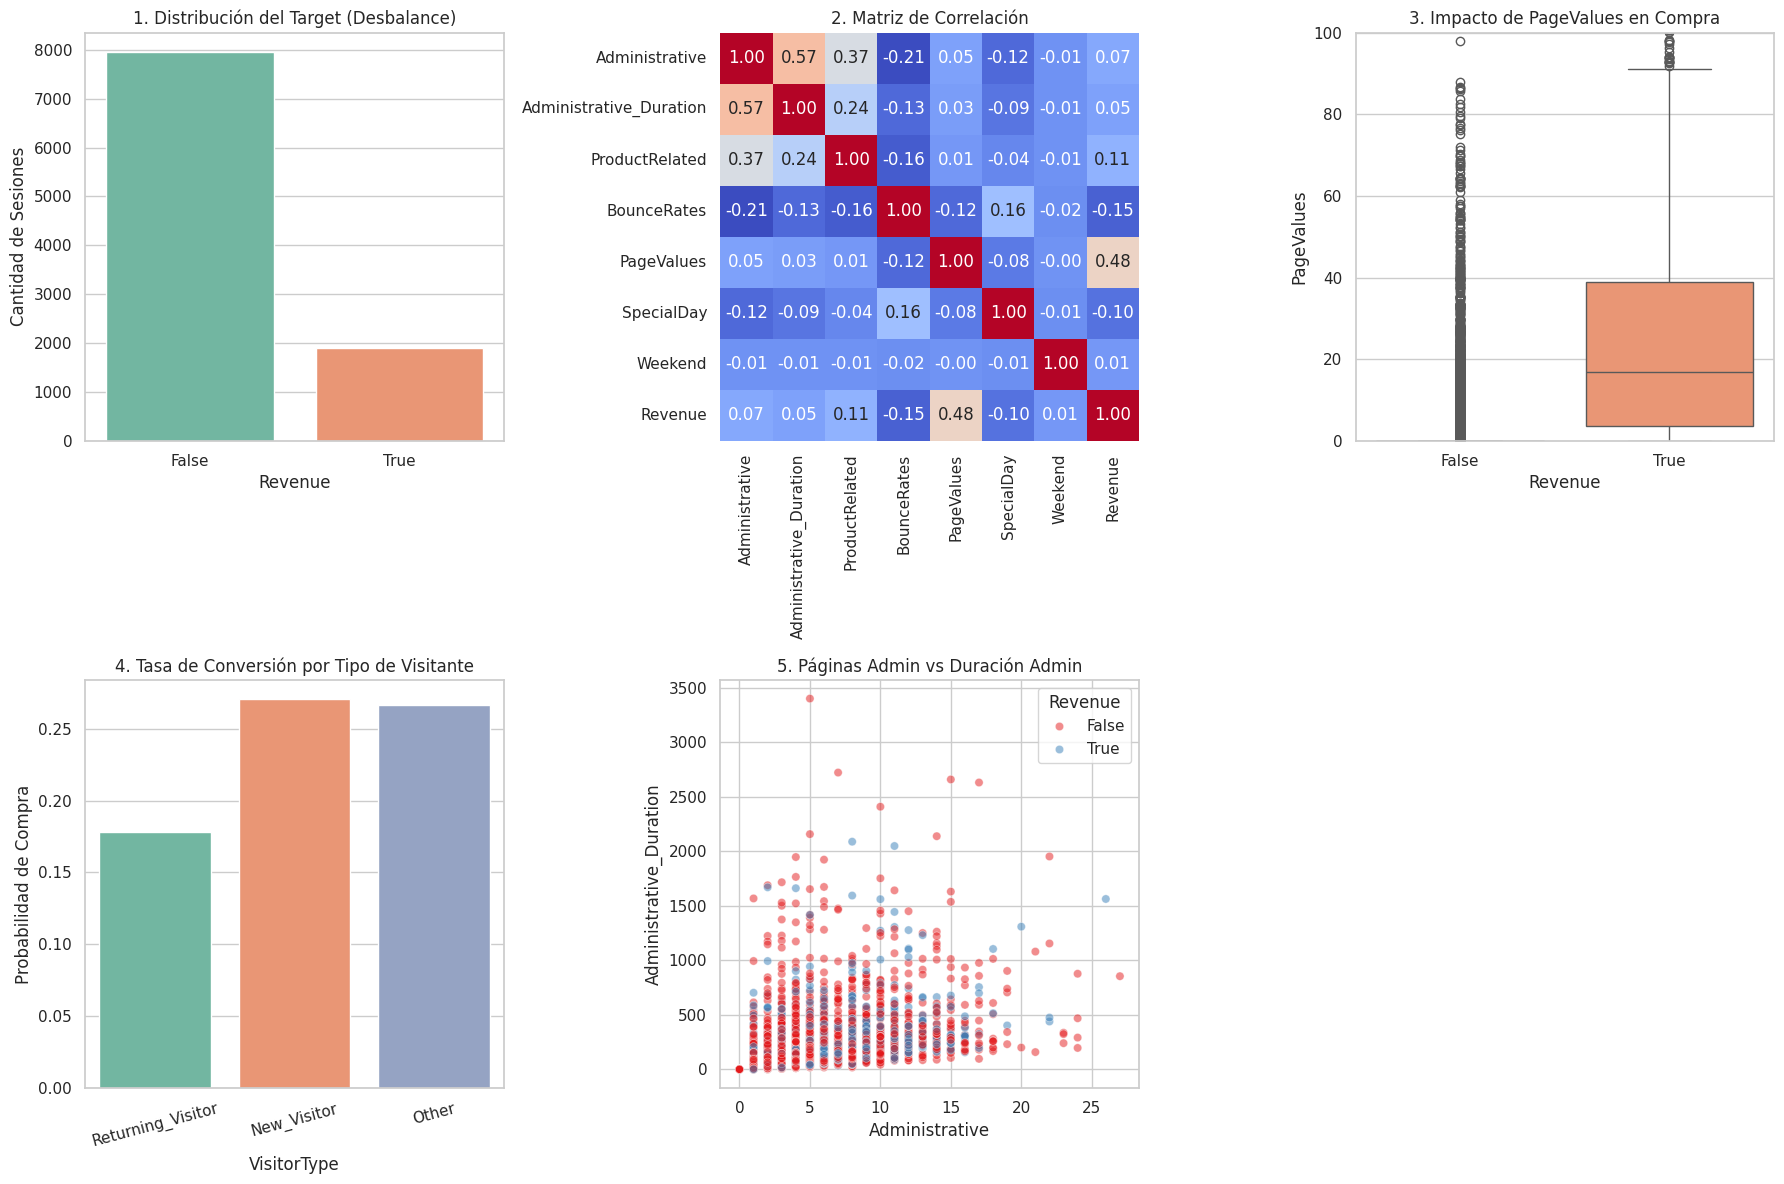

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual general
sns.set_theme(style="whitegrid")
fig = plt.figure(figsize=(18, 12))

# --- Gráfico de Barras: Distribución del Target ---
plt.subplot(2, 3, 1)
sns.countplot(data=df_limpio, x='Revenue', palette='Set2')
plt.title('1. Distribución del Target (Desbalance)')
plt.ylabel('Cantidad de Sesiones')

# --- Matriz de Correlación (Requisito explícito de la guía) ---
plt.subplot(2, 3, 2)
# Usamos numeric_only=True como pide la guía para evitar errores con variables categóricas
sns.heatmap(df_limpio.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f", cbar=False)
plt.title('2. Matriz de Correlación')

# --- Boxplot: Influencia de PageValues en la compra ---
plt.subplot(2, 3, 3)
sns.boxplot(data=df_limpio, x='Revenue', y='PageValues', palette='Set2')
plt.title('3. Impacto de PageValues en Compra')
plt.ylim(0, 100) # Limitamos Y para ver mejor la caja, ignorando outliers extremos visualmente

# --- Gráfico de Barras (Promedio): Tipo de Visitante vs Compra ---
plt.subplot(2, 3, 4)
sns.barplot(data=df_limpio, x='VisitorType', y='Revenue', palette='Set2', errorbar=None)
plt.title('4. Tasa de Conversión por Tipo de Visitante')
plt.xticks(rotation=15)
plt.ylabel('Probabilidad de Compra')

# --- Scatterplot: Multicolinealidad (Páginas vs Tiempo) ---
plt.subplot(2, 3, 5)
sns.scatterplot(data=df_limpio, x='Administrative', y='Administrative_Duration', hue='Revenue', alpha=0.5, palette='Set1')
plt.title('5. Páginas Admin vs Duración Admin')

plt.tight_layout()
plt.show()

In [9]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

X_prep = X_limpio.copy()

print("--- ENCODING DE VARIABLES BOOLEANAS ---")
# Convertimos True/False a 1/0 para que el modelo lo entienda
X_prep['Weekend'] = X_prep['Weekend'].astype(int)
y_prep = y_limpio.astype(int)
print("Variable 'Weekend' y Target 'Revenue' convertidas a 0 y 1.")

print("\n--- ENCODING DE VARIABLES CATEGÓRICAS (One-Hot Encoding) ---")
# Convertimos texto a columnas binarias. drop_first=True evita la multicolinealidad perfecta (Dummy Variable Trap)
X_prep = pd.get_dummies(X_prep, columns=['Month', 'VisitorType'], drop_first=True)
print(f"Nuevas dimensiones tras One-Hot Encoding: {X_prep.shape[1]} columnas.")

print("\n--- ESTANDARIZACIÓN DE VARIABLES NUMÉRICAS ---")
# Seleccionamos las columnas numéricas originales
cols_numericas = [
    'Administrative', 'Administrative_Duration', 'ProductRelated',
    'BounceRates', 'PageValues', 'SpecialDay'
]

# Aplicamos StandardScaler (Media = 0, Desviación Estándar = 1)
scaler = StandardScaler()
X_prep[cols_numericas] = scaler.fit_transform(X_prep[cols_numericas])
print("Variables numéricas estandarizadas.\n")

print("--- VISTA FINAL DE LOS DATOS PREPARADOS (X_prep) ---")
display(X_prep.head(3))

--- ENCODING DE VARIABLES BOOLEANAS ---
Variable 'Weekend' y Target 'Revenue' convertidas a 0 y 1.

--- ENCODING DE VARIABLES CATEGÓRICAS (One-Hot Encoding) ---
Nuevas dimensiones tras One-Hot Encoding: 18 columnas.

--- ESTANDARIZACIÓN DE VARIABLES NUMÉRICAS ---
Variables numéricas estandarizadas.

--- VISTA FINAL DE LOS DATOS PREPARADOS (X_prep) ---


,Administrative,Administrative_Duration,ProductRelated,BounceRates,PageValues,SpecialDay,Weekend,Month_Dec,Month_Feb,Month_Jul,Month_June,Month_Mar,Month_May,Month_Nov,Month_Oct,Month_Sep,VisitorType_Other,VisitorType_Returning_Visitor
0,-0.831392,-0.525201,-0.775709,6.316814,-0.359264,-0.316779,0,False,True,False,False,False,False,False,False,False,False,True
1,-0.831392,-0.525201,-0.754709,-0.474153,-0.359264,-0.316779,0,False,True,False,False,False,False,False,False,False,False,True
3,-0.831392,-0.525201,-0.754709,1.223589,-0.359264,-0.316779,0,False,True,False,False,False,False,False,False,False,False,True


In [10]:
from sklearn.model_selection import train_test_split

# Primera división: Sacamos el 70% para Entrenamiento y dejamos un 30% Temporal
# Usamos stratify=y_prep para mantener el mismo porcentaje de compras en ambos lados
X_train, X_temp, y_train, y_temp = train_test_split(
    X_prep, y_prep, test_size=0.30, random_state=42, stratify=y_prep
)

# Segunda división: Partimos el conjunto Temporal a la mitad (15% Validación, 15% Test)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print("--- PARTICIÓN DEL DATASET (TRAIN / VALIDATION / TEST) ---")
print(f"Total original de registros limpios: {X_prep.shape[0]}\n")

print(f"1. DATASET DE TRAINING   (70%): {X_train.shape[0]} registros.")
print(f"2. DATASET DE VALIDATION (15%): {X_val.shape[0]} registros.")
print(f"3. DATASET DE TESTING    (15%): {X_test.shape[0]} registros.")

print("\nValidación de balance de clases (Proporción de compras en Test):")
print(y_test.value_counts(normalize=True).round(3))

--- PARTICIÓN DEL DATASET (TRAIN / VALIDATION / TEST) ---
Total original de registros limpios: 9859

1. DATASET DE TRAINING   (70%): 6901 registros.
2. DATASET DE VALIDATION (15%): 1479 registros.
3. DATASET DE TESTING    (15%): 1479 registros.

Validación de balance de clases (Proporción de compras en Test):
Revenue
0    0.807
1    0.193
Name: proportion, dtype: float64


In [11]:
from sklearn.linear_model import LogisticRegression

print("--- ENTRENAMIENTO DEL MODELO BASE ---")

# Inicializamos el modelo de Regresión Logística
# Agregamos random_state=42 para que el resultado sea reproducible (siempre dé lo mismo)
modelo_base = LogisticRegression(random_state=42)

# ntrenamos el modelo usando los datos de TRAINING
# Aquí es donde el algoritmo aprende los patrones (X_train) y sus respuestas (y_train)
modelo_base.fit(X_train, y_train)

# Mensaje de confirmación
print("¡Modelo Base (Regresión Logística) entrenado exitosamente!")
print("\nDetalles del objeto modelo:")
print(modelo_base)

--- ENTRENAMIENTO DEL MODELO BASE ---
¡Modelo Base (Regresión Logística) entrenado exitosamente!

Detalles del objeto modelo:
LogisticRegression(random_state=42)


--- FASE 10: PREDICCIONES Y EVALUACIÓN DEL MODELO BASE ---
Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.86      0.97      0.92      1193
           1       0.77      0.35      0.48       286

    accuracy                           0.85      1479
   macro avg       0.82      0.66      0.70      1479
weighted avg       0.85      0.85      0.83      1479



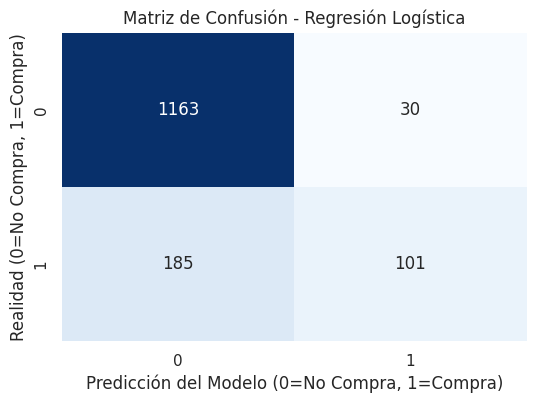

In [12]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

print("--- FASE 10: PREDICCIONES Y EVALUACIÓN DEL MODELO BASE ---")

# Generamos las predicciones usando los datos que el modelo NUNCA ha visto (X_test)
predicciones_base = modelo_base.predict(X_test)

# Imprimimos el reporte de clasificación exigido por la guía
print("Reporte de Clasificación:")
print(classification_report(y_test, predicciones_base))

# Generamos la Matriz de Confusión visual para el informe
matriz = confusion_matrix(y_test, predicciones_base)

plt.figure(figsize=(6, 4))
sns.heatmap(matriz, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Matriz de Confusión - Regresión Logística')
plt.xlabel('Predicción del Modelo (0=No Compra, 1=Compra)')
plt.ylabel('Realidad (0=No Compra, 1=Compra)')
plt.show()

In [14]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
import pandas as pd

print("--- ENTRENAMIENTO DEL SEGUNDO MODELO (RANDOM FOREST) ---")

# Inicializar y entrenar el modelo Random Forest
# class_weight='balanced' penaliza fuertemente al modelo si se equivoca en la clase minoritaria (compras)
modelo_rf = RandomForestClassifier(random_state=42, class_weight='balanced')
modelo_rf.fit(X_train, y_train)

# Generar Predicciones sobre el set de Test
predicciones_rf = modelo_rf.predict(X_test)

# Imprimir el reporte detallado
print("Reporte de Clasificación (Random Forest):")
print(classification_report(y_test, predicciones_rf))

# Extraer métricas de Random Forest (Enfocadas en Clase 1 - Compras)
acc_rf = round(accuracy_score(y_test, predicciones_rf), 2)
prec_rf = round(precision_score(y_test, predicciones_rf), 2)
rec_rf = round(recall_score(y_test, predicciones_rf), 2)
f1_rf = round(f1_score(y_test, predicciones_rf), 2)

# Métricas de tu Regresión Logística
acc_lr = 0.85
prec_lr = 0.77
rec_lr = 0.35
f1_lr = 0.48

# Construir Tabla Comparativa
tabla_comparativa = pd.DataFrame({
    'Modelo': ['Regresión Logística', 'Random Forest', 'Red Neuronal'],
    'Accuracy': [acc_lr, acc_rf, 'Pendiente (Fase 12)'],
    'Precision (Clase 1)': [prec_lr, prec_rf, 'Pendiente (Fase 12)'],
    'Recall (Clase 1)': [rec_lr, rec_rf, 'Pendiente (Fase 12)'],
    'F1-Score (Clase 1)': [f1_lr, f1_rf, 'Pendiente (Fase 12)']
})

print("\n--- TABLA COMPARATIVA DE MODELOS ---")
display(tabla_comparativa)

--- ENTRENAMIENTO DEL SEGUNDO MODELO (RANDOM FOREST) ---
Reporte de Clasificación (Random Forest):
              precision    recall  f1-score   support

           0       0.90      0.93      0.92      1193
           1       0.67      0.55      0.60       286

    accuracy                           0.86      1479
   macro avg       0.78      0.74      0.76      1479
weighted avg       0.85      0.86      0.85      1479


--- TABLA COMPARATIVA DE MODELOS ---


,Modelo,Accuracy,Precision (Clase 1),Recall (Clase 1),F1-Score (Clase 1)
0,Regresión Logística,0.85,0.77,0.35,0.48
1,Random Forest,0.86,0.67,0.55,0.6
2,Red Neuronal,Pendiente (Fase 12),Pendiente (Fase 12),Pendiente (Fase 12),Pendiente (Fase 12)


In [16]:
from keras.models import Sequential
from keras.layers import Dense, Input

print("--- CONSTRUCCIÓN DE LA ARQUITECTURA DE LA RED NEURONAL ---")

# Definimos la arquitectura Sequential usando las mejores prácticas actuales
modelo_nn = Sequential([
    # Capa de Entrada: Definimos explícitamente la forma de los datos (18 variables)
    Input(shape=(X_train.shape[1],)),

    # Capa oculta 1: Recibe los datos de la capa Input
    Dense(32, activation='relu'),

    # Capa oculta 2
    Dense(16, activation='relu'),

    # Capa oculta 3
    Dense(8, activation='relu'),

    # Capa de salida: 1 neurona con activación Sigmoid para obtener la probabilidad de compra
    Dense(1, activation='sigmoid')
])

# 2. Imprimimos el resumen de la arquitectura para el reporte
modelo_nn.summary()

--- CONSTRUCCIÓN DE LA ARQUITECTURA DE LA RED NEURONAL ---


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 32)             │           608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,281 (5.00 KB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
print("--- COMPILACIÓN Y ENTRENAMIENTO ---")

# Compilación del modelo
modelo_nn.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("Modelo compilado exitosamente. Iniciando entrenamiento...\n")

# Entrenamiento del modelo
# Guardamos el resultado en la variable 'historial'
historial = modelo_nn.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_val, y_val),
    verbose=1 # Mostrará el progreso línea
)

print("\n¡Entrenamiento de la Red Neuronal finalizado!")

--- COMPILACIÓN Y ENTRENAMIENTO ---
Modelo compilado exitosamente. Iniciando entrenamiento...

Epoch 1/100
216/216 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8186 - loss: 0.4245 - val_accuracy: 0.8634 - val_loss: 0.3471
Epoch 2/100
216/216 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8667 - loss: 0.3162 - val_accuracy: 0.8654 - val_loss: 0.3200
Epoch 3/100
216/216 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8728 - loss: 0.2984 - val_accuracy: 0.8675 - val_loss: 0.3190
Epoch 4/100
216/216 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8754 - loss: 0.2930 - val_accuracy: 0.8702 - val_loss: 0.3144
Epoch 5/100
216/216 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8770 - loss: 0.2883 - val_accuracy: 0.8729 - val_loss: 0.3057
Epoch 6/100
216/216 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8783 - loss: 0.2840 - val_accuracy: 0.8749 - val_loss: 0.3012
Epoch 7/100
216/216 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8810 - loss: 0.2804 - val_accuracy: 0.8756 - val_loss: 0.3002
Ep

--- CURVAS DE APRENDIZAJE ---


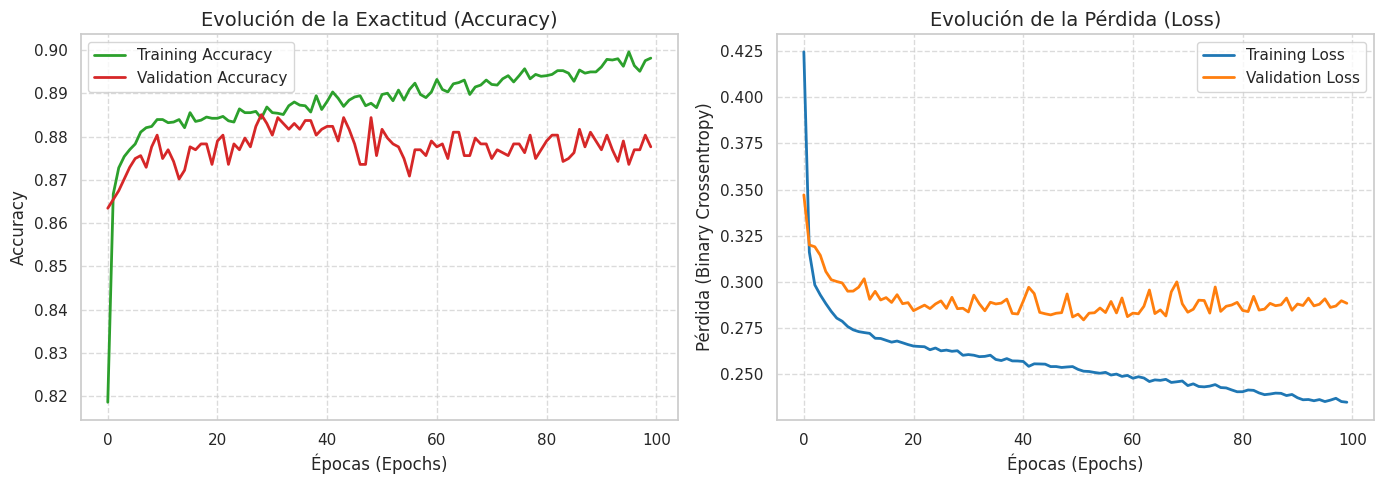

In [18]:
import matplotlib.pyplot as plt

print("--- CURVAS DE APRENDIZAJE ---")

# Configuramos el tamaño del lienzo para dos gráficos lado a lado
plt.figure(figsize=(14, 5))

# --- Gráfico de Exactitud (Accuracy) ---
plt.subplot(1, 2, 1)
plt.plot(historial.history['accuracy'], label='Training Accuracy', color='#2ca02c', linewidth=2)
plt.plot(historial.history['val_accuracy'], label='Validation Accuracy', color='#d62728', linewidth=2)
plt.title('Evolución de la Exactitud (Accuracy)', fontsize=14)
plt.xlabel('Épocas (Epochs)', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# --- Gráfico de Función de Pérdida (Loss) ---
plt.subplot(1, 2, 2)
plt.plot(historial.history['loss'], label='Training Loss', color='#1f77b4', linewidth=2)
plt.plot(historial.history['val_loss'], label='Validation Loss', color='#ff7f0e', linewidth=2)
plt.title('Evolución de la Pérdida (Loss)', fontsize=14)
plt.xlabel('Épocas (Epochs)', fontsize=12)
plt.ylabel('Pérdida (Binary Crossentropy)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [20]:
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score
from keras.models import Sequential
from keras.layers import Dense, Input

# Función auxiliar para automatizar los experimentos
def entrenar_evaluar_nn(arquitectura, capas, epochs, batch_size):
    modelo = Sequential()
    modelo.add(Input(shape=(X_train.shape[1],)))

    for neuronas in capas:
        modelo.add(Dense(neuronas, activation='relu'))

    modelo.add(Dense(1, activation='sigmoid'))

    # Compilamos
    modelo.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

    # Entrenamos (verbose=0 para ocultar la barra de progreso y no saturar la pantalla)
    modelo.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, verbose=0)

    # Predecimos sobre el set de Test oculto
    pred_probs = modelo.predict(X_test, verbose=0)
    pred_clases = (pred_probs > 0.5).astype(int)

    # Calculamos métricas enfocadas en la clase 1
    acc = round(accuracy_score(y_test, pred_clases), 4)
    f1 = round(f1_score(y_test, pred_clases), 4)

    return [arquitectura, epochs, acc, f1]

print("--- EJECUTANDO 3 EXPERIMENTOS... (30-60 s) ---")

# Experimento A: Arquitectura base anterior, pero reducida a 50 epochs
exp_a = entrenar_evaluar_nn('32-16-8-1', [32, 16, 8], 50, 32)

# Experimento B: Reducción de complejidad (Menos capas y neuronas)
exp_b = entrenar_evaluar_nn('16-8-1', [16, 8], 50, 32)

# Experimento C: Aumento de complejidad y tamaño de lote (Batch Size)
exp_c = entrenar_evaluar_nn('64-32-16-1', [64, 32, 16], 50, 64)

# Construcción de la tabla comparativa exigida
tabla_experimentos = pd.DataFrame(
    [exp_a, exp_b, exp_c],
    columns=['Arquitectura', 'Epochs', 'Accuracy', 'F1']
)
tabla_experimentos.insert(0, 'Experimento', ['A', 'B', 'C'])

print("\n--- TABLA COMPARATIVA DE EXPERIMENTOS ---")
display(tabla_experimentos)

--- EJECUTANDO 3 EXPERIMENTOS... (30-60 s) ---

--- TABLA COMPARATIVA DE EXPERIMENTOS ---


,Experimento,Arquitectura,Epochs,Accuracy,F1
0,A,32-16-8-1,50,0.8600,0.6202
1,B,16-8-1,50,0.8621,0.6194
2,C,64-32-16-1,50,0.8682,0.6341


In [21]:
from keras.models import Sequential
from keras.layers import Dense, Dropout, Input
from sklearn.metrics import classification_report, accuracy_score, f1_score
import matplotlib.pyplot as plt

print("--- APLICACIÓN DE REGULARIZACIÓN (DROPOUT) ---")

# Construcción del modelo regularizado
modelo_regularizado = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(16, activation='relu'),
    Dropout(0.3),                 # Apaga el 30% de las neuronas aleatoriamente para evitar sobreajuste
    Dense(8, activation='relu'),
    Dropout(0.2),                 # Apaga el 20% en la siguiente capa
    Dense(1, activation='sigmoid')
])

# Compilación
modelo_regularizado.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Entrenamiento con 50 épocas
historial_reg = modelo_regularizado.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_val, y_val),
    verbose=0
)

print("¡Modelo regularizado entrenado exitosamente!\n")

# Evaluación comparativa antes y después en el set de Test
pred_prob_reg = modelo_regularizado.predict(X_test, verbose=0)
pred_clases_reg = (pred_prob_reg > 0.5).astype(int)

print("Reporte de Clasificación (Modelo Regularizado con Dropout):")
print(classification_report(y_test, pred_clases_reg))

--- APLICACIÓN DE REGULARIZACIÓN (DROPOUT) ---
¡Modelo regularizado entrenado exitosamente!

Reporte de Clasificación (Modelo Regularizado con Dropout):
              precision    recall  f1-score   support

           0       0.91      0.93      0.92      1193
           1       0.66      0.59      0.63       286

    accuracy                           0.86      1479
   macro avg       0.78      0.76      0.77      1479
weighted avg       0.86      0.86      0.86      1479



In [22]:
import pandas as pd
import numpy as np

print("--- SIMULACIÓN DE PREDICCIÓN EN TIEMPO REAL ---")

# Creamos un diccionario con los datos de un nuevo visitante simulado
# (Supongamos a un usuario que navegó 5 páginas administrativas, pasó tiempo, y tiene un PageValues alto)
nuevo_usuario_dict = {
    'Administrative': 3,
    'Administrative_Duration': 45.5,
    'Informational': 0,
    'Informational_Duration': 0.0,
    'ProductRelated': 15,
    'ProductRelated_Duration': 620.0,
    'BounceRates': 0.01,
    'ExitRates': 0.02,
    'PageValues': 45.8,  # Alto valor de página (indica cercanía al checkout)
    'SpecialDay': 0.0,
    'Month': 'Nov',      # Mes comercial fuerte (Black Friday / Noviembre)
    'OperatingSystems': 2,
    'Browser': 2,
    'Region': 1,
    'TrafficType': 2,
    'VisitorType': 'Returning_Visitor',
    'Weekend': False
}

# Convertimos el diccionario en un DataFrame y replicamos el preprocesamiento
df_nuevo = pd.DataFrame([nuevo_usuario_dict])

# Aplicamos el mismo One-Hot Encoding que hicimos en la Fase 7 asegurando las 18 columnas
df_nuevo_prep = pd.get_dummies(df_nuevo, columns=['Month', 'VisitorType'], drop_first=True)

# Aseguramos que tenga exactamente las mismas columnas que vio el modelo (reindexando y rellenando con 0s faltantes)
df_nuevo_prep = df_nuevo_prep.reindex(columns=X_prep.columns, fill_value=0)

# Estandarizamos las variables numéricas usando el MISMO scaler entrenado en la Fase 7
cols_numericas = ['Administrative', 'Administrative_Duration', 'ProductRelated', 'BounceRates', 'PageValues', 'SpecialDay']
df_nuevo_prep[cols_numericas] = scaler.transform(df_nuevo_prep[cols_numericas])

# Realizamos la predicción con nuestra Red Neuronal Regularizada
probabilidad_compra = modelo_regularizado.predict(df_nuevo_prep, verbose=0)[0][0]
prediccion_clase = (probabilidad_compra > 0.5).astype(int)

print(f"\nResultado de la simulación para el nuevo visitante:")
print(f" - Probabilidad calculada de compra: {probabilidad_compra * 100:.2f}%")
print(f" - Decisión del modelo: {'SÍ COMPRA (1)' if prediccion_clase == 1 else 'NO COMPRA (0)'}")

--- SIMULACIÓN DE PREDICCIÓN EN TIEMPO REAL ---

Resultado de la simulación para el nuevo visitante:
 - Probabilidad calculada de compra: 86.03%
 - Decisión del modelo: SÍ COMPRA (1)
